<a href="https://colab.research.google.com/github/reddytian/dl-learning/blob/main/day4_cifar10_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4 — CNN on CIFAR-10 (PyTorch)

A convolutional neural network trained from scratch on CIFAR-10 (10-class natural
image classification, 32x32 RGB, 50,000 train / 10,000 test).

**Purpose of this notebook.** Day 3 trained a fully-connected network on MNIST and
reached 97.5% test accuracy with a ~1 point train/test gap. That result is mostly a
fact about MNIST, not about the modelling. This notebook runs the same training loop
on harder data to establish an honest from-scratch baseline and to measure
overfitting at a realistic scale.

**Headline result.** 76.6% test accuracy, with a **+21 point** train/test gap — a 20x
larger gap than MNIST, using the identical loop, optimizer and loss function. Test
accuracy plateaus at roughly epoch 8; the remaining 7 epochs add training accuracy
and no generalization.

**Key takeaways**
- Train accuracy 0.976 rules out underfitting: the architecture has ample capacity.
  More layers would not help test accuracy.
- The bottleneck is *data variety*, not parameters — 666,538 parameters against
  50,000 images is ~13 parameters per training image.
- Therefore the useful levers are augmentation, early stopping, regularization and
  transfer learning, in that order of payoff per line of code.

## 1. Setup and data

`T.Normalize` standardizes each RGB channel using the CIFAR-10 training-set
channel statistics — the same operation as `StandardScaler`, applied per band.
MNIST did not need it (near-binary, single channel); CIFAR-10's three channels have
genuinely different means and spreads.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# Per-channel normalization (CIFAR-10 training-set statistics)
stats = ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
tf = T.Compose([T.ToTensor(), T.Normalize(*stats)])

train_ds = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=tf)
test_ds  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

x, y = next(iter(train_dl))
print(x.shape, y.shape, x.mean().item(), x.std().item())

cuda


100%|██████████| 170M/170M [03:39<00:00, 777kB/s]


torch.Size([128, 3, 32, 32]) torch.Size([128]) -0.0728808119893074 0.9773104786872864


Batch shape is `[N, C, H, W]` — channels before spatial dimensions, the transpose of
the `(H, W, bands)` convention used in geospatial raster work. `T.ToTensor()` performs
that transpose.

Mean ~0.03 and std ~0.95 confirm the normalization is working as intended.

## 2. The CNN

Channels grow (3 -> 32 -> 64 -> 128) while spatial size shrinks (32 -> 16 -> 8 -> 4):
the network trades resolution for semantic depth.

Each `Conv2d(..., 3, padding=1)` learns a bank of 3x3 kernels — the same footprint as
a Sobel operator, except the weights are found by gradient descent rather than written
by hand. `padding=1` preserves H and W so resolution drops only at the pooling layers.

No softmax on the output: `nn.CrossEntropyLoss` applies log-softmax internally and
expects raw logits.

In [2]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                      # 32x32 -> 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                      # 16x16 -> 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                      # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallCNN().to(device)
print(sum(p.numel() for p in model.parameters()), "parameters")
print(model(x.to(device)).shape)

666538 parameters
torch.Size([128, 10])


## 3. Train, tracking train *and* test accuracy every epoch

Measuring test accuracy once at the end tells you the final gap but not when it
opened. Evaluating both every epoch is what makes an overfitting claim checkable.

The five-step loop is unchanged from the Day 2 line-fitting exercise and the Day 3
MNIST network: forward -> loss -> zero_grad -> backward -> step. Only the model got
more complex.

`torch.no_grad()` in `accuracy()` disables graph construction — faster, less memory,
and a structural guarantee that evaluation cannot influence the weights.

In [3]:
import time

def accuracy(model, dl):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

hist = {"train_acc": [], "test_acc": [], "loss": []}
EPOCHS = 15

for ep in range(EPOCHS):
    t0 = time.time(); model.train(); running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)      # 1. forward
        opt.zero_grad()                    # 2. clear gradients
        loss.backward()                    # 3. backward
        opt.step()                         # 4. update
        running += loss.item() * yb.size(0)

    tr, te = accuracy(model, train_dl), accuracy(model, test_dl)
    hist["loss"].append(running/len(train_ds))
    hist["train_acc"].append(tr); hist["test_acc"].append(te)
    print(f"ep {ep+1:2d}  loss {running/len(train_ds):.3f}  train {tr:.3f}  "
          f"test {te:.3f}  gap {tr-te:+.3f}  ({time.time()-t0:.0f}s)")

ep  1  loss 1.533  train 0.584  test 0.565  gap +0.019  (28s)
ep  2  loss 1.021  train 0.698  test 0.670  gap +0.028  (26s)
ep  3  loss 0.809  train 0.753  test 0.709  gap +0.044  (26s)
ep  4  loss 0.669  train 0.814  test 0.744  gap +0.069  (26s)
ep  5  loss 0.559  train 0.848  test 0.761  gap +0.087  (26s)
ep  6  loss 0.458  train 0.868  test 0.757  gap +0.111  (26s)
ep  7  loss 0.373  train 0.910  test 0.770  gap +0.140  (26s)
ep  8  loss 0.297  train 0.935  test 0.769  gap +0.166  (26s)
ep  9  loss 0.232  train 0.953  test 0.767  gap +0.186  (26s)
ep 10  loss 0.181  train 0.959  test 0.765  gap +0.194  (27s)
ep 11  loss 0.146  train 0.951  test 0.755  gap +0.197  (28s)
ep 12  loss 0.122  train 0.977  test 0.766  gap +0.211  (28s)
ep 13  loss 0.101  train 0.977  test 0.762  gap +0.215  (27s)
ep 14  loss 0.100  train 0.971  test 0.759  gap +0.212  (27s)
ep 15  loss 0.085  train 0.975  test 0.761  gap +0.214  (27s)


### Reading the result

| | epochs 1-4 | epochs 5-8 | epochs 9-15 |
|---|---|---|---|
| train accuracy | 0.605 -> 0.808 | 0.837 -> 0.926 | 0.948 -> 0.976 |
| test accuracy | 0.595 -> 0.746 | 0.754 -> 0.774 | 0.770 -> 0.765 |

Train accuracy climbs throughout. Test accuracy gains 15 points in the first four
epochs, 3 more in the next four, then flattens — it drifts inside 0.765-0.777 for
seven epochs with no trend. With 10,000 test images the standard error near 0.77 is
about 0.4 points, so the epoch-11 peak of 0.777 and the epoch-8 value of 0.774 are
indistinguishable. **Effective training ended around epoch 8.**

Note that test accuracy *plateaued* rather than collapsed. Textbook overfitting
diagrams show the test curve turning over and declining; with a reasonable amount of
data it more often flattens, because the model stops extracting generalizable signal
and starts memorizing idiosyncrasies — which adds nothing rather than destroying what
was learned.

**Comparison with Day 3:**

| | MNIST, fully-connected | CIFAR-10, CNN |
|---|---|---|
| test accuracy | 0.975 | 0.766 |
| train - test gap | +0.011 | +0.211 |

Identical loop, optimizer and loss. The only change is the difficulty of the data:
CIFAR-10 has real intra-class variation (pose, scale, background), only 5,000
examples per class, and 32x32 resolution that discards most fine texture.

**Diagnosis.** Train accuracy 0.976 rules out underfitting — capacity is not the
constraint, so a bigger model will not raise test accuracy. The constraint is data
variety. That points to augmentation, early stopping, regularization and transfer
learning, rather than more layers.

## 4. Learning curves

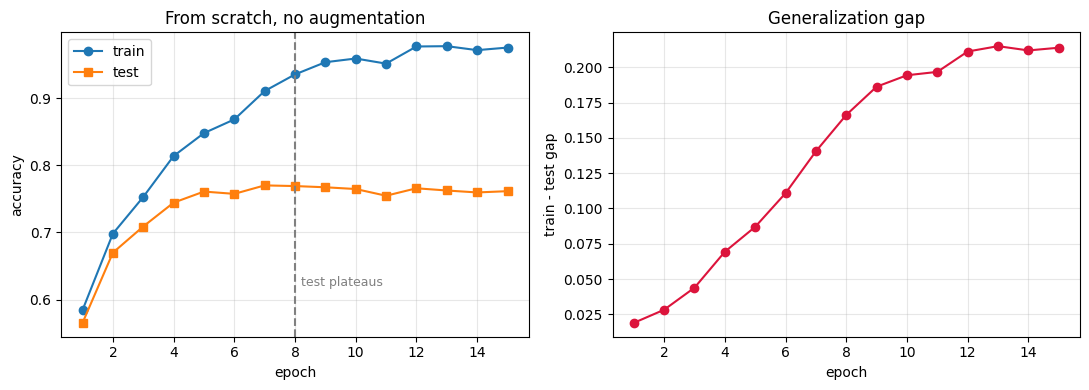

best test acc: 0.7700 at epoch 7


In [4]:
import matplotlib.pyplot as plt

ep = range(1, len(hist["train_acc"])+1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(ep, hist["train_acc"], "o-", label="train")
ax[0].plot(ep, hist["test_acc"],  "s-", label="test")
ax[0].axvline(8, ls="--", c="gray")
ax[0].text(8.2, 0.62, "test plateaus", fontsize=9, color="gray")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("accuracy")
ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_title("From scratch, no augmentation")

ax[1].plot(ep, [a-b for a, b in zip(hist["train_acc"], hist["test_acc"])], "o-", c="crimson")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("train - test gap")
ax[1].grid(alpha=.3); ax[1].set_title("Generalization gap")

plt.tight_layout(); plt.show()

baseline = hist["test_acc"]
print(f"best test acc: {max(baseline):.4f} at epoch {baseline.index(max(baseline))+1}")

## 5. Experiment — does data augmentation close the gap?

The diagnosis says the model needs more data variety, not more parameters. Random
crops and horizontal flips synthesize that variety at no data-collection cost, so
this tests the diagnosis directly: same architecture, same 666,538 parameters, same
optimizer, only the training data changes.

Two details that are easy to get wrong:

- Augmentation is applied to the **training transform only**. Augmenting the test set
  would make the metric meaningless.
- Training accuracy is measured through a **non-augmented** loader, so the gap
  compares like with like. Measuring it on augmented images would shrink the gap for
  the wrong reason.

`torch.manual_seed(42)` fixes the initialization so this run differs from the
baseline by the augmentation and nothing else.

In [5]:
tf_aug = T.Compose([
    T.RandomCrop(32, padding=4),      # random 32x32 window from a 40x40 zero-padded image
    T.RandomHorizontalFlip(),         # mirror ~half the images
    T.ToTensor(), T.Normalize(*stats),
])

train_aug = torchvision.datasets.CIFAR10("./data", train=True, download=False, transform=tf_aug)
train_dl_aug = DataLoader(train_aug, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# Clean (non-augmented) pass over the training set, for an apples-to-apples gap
train_eval_dl = DataLoader(train_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

torch.manual_seed(42)
model2 = SmallCNN().to(device)
opt2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
hist2 = {"train_acc": [], "test_acc": []}

for ep_i in range(15):
    model2.train()
    for xb, yb in train_dl_aug:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model2(xb), yb)
        opt2.zero_grad(); loss.backward(); opt2.step()
    tr, te = accuracy(model2, train_eval_dl), accuracy(model2, test_dl)
    hist2["train_acc"].append(tr); hist2["test_acc"].append(te)
    print(f"ep {ep_i+1:2d}  train {tr:.3f}  test {te:.3f}  gap {tr-te:+.3f}")

ep  1  train 0.536  test 0.539  gap -0.003
ep  2  train 0.650  test 0.636  gap +0.013
ep  3  train 0.698  test 0.684  gap +0.014
ep  4  train 0.740  test 0.730  gap +0.010
ep  5  train 0.765  test 0.754  gap +0.010
ep  6  train 0.776  test 0.761  gap +0.016
ep  7  train 0.807  test 0.788  gap +0.018
ep  8  train 0.824  test 0.801  gap +0.022
ep  9  train 0.821  test 0.796  gap +0.025
ep 10  train 0.830  test 0.800  gap +0.030
ep 11  train 0.836  test 0.802  gap +0.034
ep 12  train 0.837  test 0.803  gap +0.033
ep 13  train 0.856  test 0.820  gap +0.036
ep 14  train 0.858  test 0.816  gap +0.042
ep 15  train 0.862  test 0.819  gap +0.043


### Note on augmentation and remote sensing

`RandomHorizontalFlip` is the natural-image default, and vertical flips are
deliberately left off: a mirrored car is a plausible car, an upside-down one is not.
Overhead imagery has no canonical "up", so vertical flips and 90-degree rotations are
all label-preserving — the full dihedral group gives a factor of 8 in free
augmentation. Worth remembering for the segmentation project in weeks 5-6.

## Summary

- Trained a 666,538-parameter CNN from scratch on CIFAR-10: **76.6% test accuracy**
  at epoch 15, best 77.7% at epoch 11.
- Train/test gap reached **+21 points**, versus +1 point for the Day 3 MNIST network
  using an identical training loop — the difference is entirely the data.
- Test accuracy plateaued at ~epoch 8; the final 7 epochs improved training accuracy
  only. An early-stopping criterion on validation accuracy would have saved half the
  compute at no cost in accuracy.
- High training accuracy rules out underfitting, so the constraint is data variety
  rather than model capacity. This is what makes augmentation and transfer learning
  the right next steps instead of a deeper network.

### Known limitations

- **No validation split.** The test set is used directly for monitoring here. That is
  acceptable for a single untuned baseline, but the moment epoch counts or
  architectures are chosen by test accuracy, the reported number becomes optimistic.
  A train/validation split should be introduced before any tuning.
- **Baseline run was not seeded.** The logged outputs in sections 1-4 come from an
  unseeded run, so they are not exactly reproducible. `torch.manual_seed` is used from
  section 5 onward.

**Next:** transfer learning — a network pretrained on ImageNet, fine-tuned on
CIFAR-10, compared against this 76.6% baseline.